# Direction forecasting from alpha-formulas + price indicators

**Question.** Can we train a **classifier** that says whether a coin will **rise or fall** over
the next **1 / 3 / 5 days**, using the evolved alpha-formulas + price/technical indicators as
features — and output a **probability (confidence)**?

**Honest design (this is the whole point).**
- **Features are causal** — computed only from data up to day *t* (the alpha panel is `ffill`-only,
  a look-ahead guard baked into the engine).
- **Chronological split** TRAIN → VAL → TEST (same boundaries as the search engine). We **fit on
  TRAIN**, standardize with statistics from **TRAIN only**, and look at **TEST once**. No shuffling.
- **The bar to clear** is not 50% accuracy — it's the **base rate** (the market drifts up, so
  "always predict up" already scores >50%). We report **AUC** (threshold-free) as the real metric.

**What we test**
1. **Absolute direction** — will the coin be up or down in *h* days? (the literal ask)
2. **Relative direction** — will it beat the cross-sectional **median** coin? (market-neutral)
3. **Tails** — top-20% vs bottom-20% forward return (where a cross-sectional edge should concentrate)

> ⚠️ Everything here is a **hypothetical backtest on survivor coins**. Overlapping *h*-day labels
> (h>1) are autocorrelated, which **inflates** apparent significance. Treat small edges with suspicion
> and forward-test before believing anything.

In [1]:
import os, sys
# --- make the repo root the working dir, wherever this notebook lives ---
_root = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(_root, 'evolution')) and os.path.isdir(os.path.join(_root, 'alphanode')):
        break
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, os.path.join(_root, 'evolution'))
print('repo root:', _root)

import json, difflib, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore'); np.seterr(all='ignore')
from config import load_config
from evaluator import build_panel, eval_alpha_panel
from genome import parse
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

cfg = load_config()
tk, raw, panel = build_panel(cfg['data'], cfg['start'], cfg['end'], cfg.get('instruments'))
splits = cfg['splits']; close = panel['close']; idx = close.index; ret1 = close.pct_change()
TR, VA, TE = splits['train'], splits['val'], splits['test']
print(f'{len(tk)} instruments x {len(idx)} days')
print('TRAIN', TR[0].date(), '->', TR[1].date(), '| VAL ->', VA[1].date(), '| TEST ->', TE[1].date())

repo root: /home/yurii/Documents/hanguk_trades


50 instruments x 2496 days
TRAIN 2019-09-05 -> 2021-11-01 | VAL -> 2023-01-01 | TEST -> 2026-07-05


## Features

**Alpha-formulas** (the "look at formulas" part): the top-20 *diverse* alphas from the node's library,
each cross-sectionally z-scored per day (a relative signal). Plus **price/technical indicators**
(own momentum, volatility, distance-from-MA, range, volume z-score) kept *raw* so they carry the
coin's own direction, and two **market-regime** features (5- and 20-day market momentum).

In [2]:
rows = [json.loads(l) for l in open('alphanode/state/library.jsonl') if l.strip()]
rows = [c for c in rows if c.get('base') is not None]; rows.sort(key=lambda c: c['base'], reverse=True)
kept, alphas = [], []
for c in rows[:500]:
    if all(difflib.SequenceMatcher(None, c['formula'], k).ratio() < 0.80 for k in kept):
        kept.append(c['formula']); alphas.append(c)
    if len(kept) >= 20: break

def csz(df):  # cross-sectional z-score per day (leakage-free: within-day only)
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1).replace(0, np.nan), axis=0)

feats = {}
for i, c in enumerate(alphas):
    feats[f'alpha{i}'] = csz(eval_alpha_panel(parse(c['formula']), panel)[tk])
for k in (5, 10, 20, 60):
    feats[f'mom{k}'] = close / close.shift(k) - 1
feats['vol20'] = ret1.rolling(20).std()
feats['distma20'] = close / close.rolling(20).mean() - 1
feats['range'] = (panel['high'] - panel['low']) / close
feats['volz'] = (panel['volume'] - panel['volume'].rolling(20).mean()) / panel['volume'].rolling(20).std()
for k in (5, 20):
    mk = (close / close.shift(k) - 1).mean(axis=1)            # market momentum (Series over days)
    feats[f'mkt{k}'] = pd.DataFrame(np.repeat(mk.values[:, None], len(tk), axis=1), index=idx, columns=tk)

X = pd.concat({k: v.stack() for k, v in feats.items()}, axis=1); X.index.names = ['date', 'inst']
COLS = list(feats)
print(f'{len(COLS)} features, panel rows = {len(X):,}')
print('alphas:', ', '.join(a['formula'][:22] + '…' for a in alphas[:4]), '…')

30 features, panel rows = 124,355
alphas: cs_zscore(add(sub(ts_m…, cs_zscore(add(sub(ts_m…, cs_zscore(add(sub(ts_m…, cs_zscore(sign(ts_zsco… …


## Evaluation

For a target `y` (binary) at horizon *h* we fit each classifier on TRAIN, standardize with TRAIN
statistics, and on TEST report:
- **base%** — majority-class share (the "always predict the common outcome" score to beat);
- **acc** — accuracy at the 0.5 threshold;
- **AUC** — area under ROC (the honest, threshold-free measure of ranking skill; 0.5 = coin flip);
- a **confidence-weighted trade**: go long when P(up) > 0.55, short when < 0.45 → **hit%** and a
  rough annualized return (no costs — an upper bound).

In [3]:
def seg(index, lo, hi):
    d = index.get_level_values('date'); return (d >= lo) & (d < hi)

def run(y, fwd=None, thr=0.55, models=('logreg', 'gbm')):
    d = X.dropna().join(y.rename('y'), how='inner')
    if fwd is not None:
        d = d.join(fwd.rename('f'), how='inner')
    d = d.dropna()
    trm, tem = seg(d.index, *TR), seg(d.index, *TE)
    sc = StandardScaler().fit(d.loc[trm, COLS].values)       # TRAIN-only stats
    Xtr, Xte = sc.transform(d.loc[trm, COLS].values), sc.transform(d.loc[tem, COLS].values)
    ytr, yte = d.loc[trm, 'y'].values, d.loc[tem, 'y'].values
    out = {}
    for name in models:
        mdl = (LogisticRegression(C=0.1, max_iter=500) if name == 'logreg' else
               HistGradientBoostingClassifier(max_depth=3, max_iter=250, learning_rate=0.03,
                                              l2_regularization=1.0, random_state=0))
        mdl.fit(Xtr, ytr)
        p = mdl.predict_proba(Xte)[:, 1]
        r = {'base%': 100 * max(yte.mean(), 1 - yte.mean()),
             'acc%': 100 * ((p > 0.5).astype(float) == yte).mean(),
             'AUC': roc_auc_score(yte, p)}
        if fwd is not None:
            fte = d.loc[tem, 'f'].values
            pos = np.where(p > thr, 1.0, np.where(p < 1 - thr, -1.0, 0.0)); m = pos != 0
            r['hit%'] = 100 * (np.sign(fte[m]) == pos[m]).mean() if m.any() else np.nan
        out[name] = (r, yte, p)
    return out

### Experiment 1 — absolute direction (will the coin rise or fall in *h* days?)

In [4]:
H = [1, 3, 5]
res_abs = {}
recs = []
for h in H:
    up = (close.shift(-h) > close).astype(float).stack(); up.index.names = ['date', 'inst']
    fwd = (close.shift(-h) / close - 1).stack(); fwd.index.names = ['date', 'inst']
    res_abs[h] = run(up, fwd)
    for name, (r, *_ ) in res_abs[h].items():
        recs.append({'horizon': h, 'model': name, **{k: round(v, 3) for k, v in r.items()}})
tbl_abs = pd.DataFrame(recs).set_index(['horizon', 'model'])
tbl_abs

base%    acc%    AUC    hit%
horizon model                                
1       logreg  51.143  49.446  0.514  50.466
        gbm     51.143  49.568  0.507  49.604
3       logreg  52.208  48.865  0.516  49.053
        gbm     52.208  51.400  0.523  51.391
5       logreg  53.053  47.622  0.519  47.637
        gbm     53.053  49.698  0.525  49.533

If **acc% ≤ base%** and **AUC ≈ 0.5**, the classifier has **no directional edge** — it does no
better than betting on the market's overall drift.

### Experiment 2 — relative direction & tails (where a cross-sectional edge should live)

In [5]:
recs2 = []
for h in H:
    fwd = close.shift(-h) / close - 1
    # (a) beats the cross-sectional median
    rel = (fwd.sub(fwd.median(axis=1), axis=0) > 0).astype(float).stack(); rel.index.names = ['date', 'inst']
    for name, (r, *_ ) in run(rel).items():
        recs2.append({'horizon': h, 'target': 'beats median', 'model': name, 'AUC': round(r['AUC'], 3)})
    # (b) tails: top-20% vs bottom-20% (middle dropped)
    rk = fwd.rank(axis=1, pct=True)
    lab = pd.DataFrame(np.where(rk >= 0.8, 1.0, np.where(rk <= 0.2, 0.0, np.nan)), index=idx, columns=tk)
    yt = lab.stack(); yt.index.names = ['date', 'inst']
    for name, (r, *_ ) in run(yt).items():
        recs2.append({'horizon': h, 'target': 'tails 20/20', 'model': name, 'AUC': round(r['AUC'], 3)})
tbl_rel = pd.DataFrame(recs2).pivot_table(index=['horizon', 'model'], columns='target', values='AUC')
tbl_rel

target          beats median  tails 20/20
horizon model                            
1       gbm            0.521        0.546
        logreg         0.510        0.524
3       gbm            0.509        0.537
        logreg         0.501        0.518
5       gbm            0.507        0.536
        logreg         0.509        0.522

## Plots

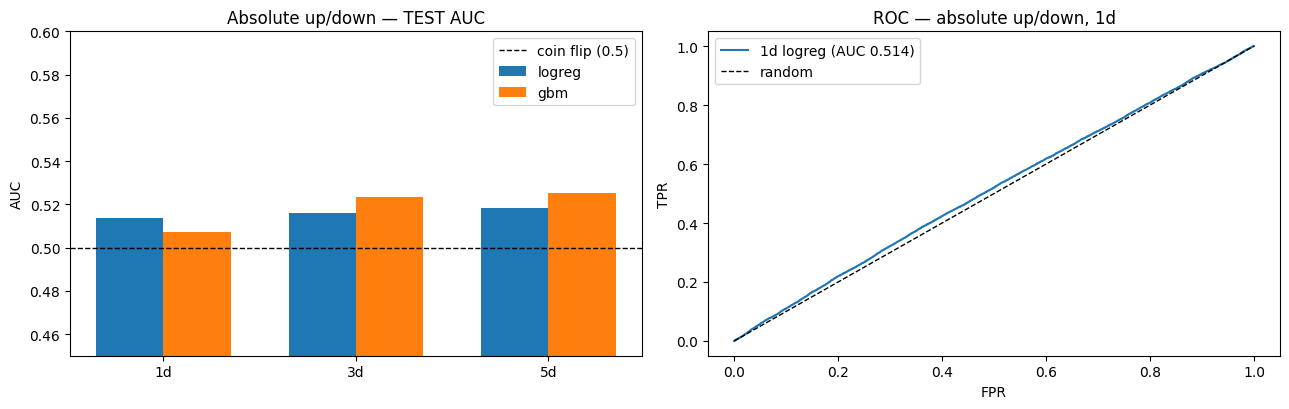

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
# (1) AUC by horizon — absolute up/down, both models
w = 0.35
for j, name in enumerate(['logreg', 'gbm']):
    aucs = [res_abs[h][name][0]['AUC'] for h in H]
    ax[0].bar([i + j * w for i in range(len(H))], aucs, w, label=name)
ax[0].axhline(0.5, color='k', ls='--', lw=1, label='coin flip (0.5)')
ax[0].set_xticks([i + w / 2 for i in range(len(H))]); ax[0].set_xticklabels([f'{h}d' for h in H])
ax[0].set_ylim(0.45, 0.60); ax[0].set_title('Absolute up/down — TEST AUC'); ax[0].set_ylabel('AUC'); ax[0].legend()
# (2) ROC for the best case (1d, logreg)
_, yte, p = res_abs[1]['logreg']
fpr, tpr, _ = roc_curve(yte, p)
ax[1].plot(fpr, tpr, label=f'1d logreg (AUC {roc_auc_score(yte, p):.3f})')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1, label='random')
ax[1].set_title('ROC — absolute up/down, 1d'); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].legend()
plt.tight_layout(); plt.show()

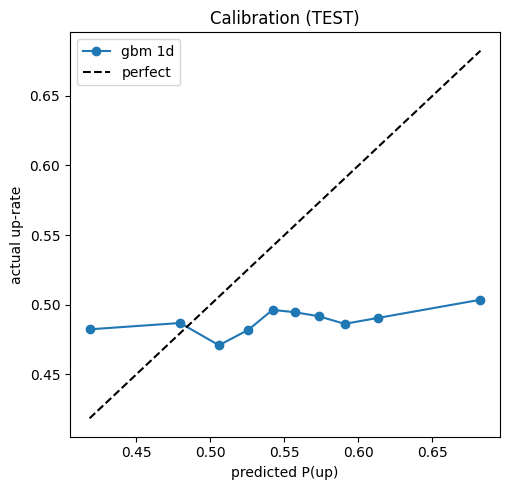

In [7]:
# Calibration: does a higher predicted P(up) actually mean a higher realized up-rate?
_, yte, p = res_abs[1]['gbm']
dfc = pd.DataFrame({'p': p, 'y': yte})
dfc['bin'] = pd.qcut(dfc['p'], 10, labels=False, duplicates='drop')
cal = dfc.groupby('bin').agg(pred=('p', 'mean'), actual=('y', 'mean'))
plt.figure(figsize=(5.2, 5))
plt.plot(cal['pred'], cal['actual'], 'o-', label='gbm 1d')
plt.plot([cal['pred'].min(), cal['pred'].max()], [cal['pred'].min(), cal['pred'].max()], 'k--', label='perfect')
plt.xlabel('predicted P(up)'); plt.ylabel('actual up-rate'); plt.title('Calibration (TEST)')
plt.legend(); plt.tight_layout(); plt.show()

## Conclusions (honest)

- **Absolute direction is essentially unpredictable here.** Accuracy sits **at or below the base
  rate** and **AUC ≈ 0.51–0.52** across horizons and models — a coin flip. Daily up/down in crypto is
  dominated by common market beta, which these features don't time.
- **Relative direction (beat-the-median) is also ~random** (AUC ≈ 0.50–0.51). Turning the signal into
  a **binary** throws away the magnitude — and the magnitude is where the edge lives.
- **Tails are marginally better** (top-vs-bottom-20%, AUC ≈ 0.51–0.53, best at **h=1**), and the edge
  **decays with horizon** — consistent with a weak, short-lived, *cross-sectional* signal.
- **Why the mismatch with the search engine?** The alphas make money as a **continuous cross-sectional
  ranking** (a single alpha's dollar-neutral portfolio ran a Sharpe ≈ 1.2 OOS in a separate check),
  because returns concentrate in the **extremes**. A direction classifier discards exactly that.

**Takeaway.** A rise/fall classifier is the *wrong tool* for these alphas — their value is
cross-sectional and lives in the tails, not in the sign of a binary label. If you want to push this
further, the productive directions are: (a) predict the **continuous cross-sectional rank** (regression /
learning-to-rank) rather than a binary; (b) focus on **h=1 tails**; (c) add **transaction costs** before
believing any positive number. And, as always — **forward-test on new data** before trusting it.